## Intelligent Network Incident Resolution System

In [ ]:
!pip install -q langgraph langchain langchain-google-genai

In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_google_genai import ChatGoogleGenerativeAI
import os

In [3]:
from google.colab import userdata

GOOGLE_API_KEY = userdata.get("GEMINI_API_KEY")

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    google_api_key=GOOGLE_API_KEY,
    temperature=0
)

## State Definition

In [4]:
# workflow state
class TelecomState(TypedDict):
    query: str

    issue_type: str
    severity: str
    impact_scope: str

    tower_status: str
    crm_status: str
    billing_status: str
    device_status: str
    outage_status: str

    route: str

    customer_response: str
    technician_notes: str
    resolution_eta: str

### Stage 1 — Complaint Understanding

In [5]:
def complaint_understanding(state: TelecomState):
    """Single LLM call — extracts issue_type, severity, impact_scope."""

    query = state["query"]

    prompt = f"""
    You are a telecom complaint analysis expert.

    Analyze the complaint below and extract:

    - issue_type
    - severity (low, medium, high, critical)
    - impact_scope (individual, multiple_users, regional)

    Complaint:
    {query}

    Return in this exact format:

    issue_type:
    severity:
    impact_scope:
    """

    response = llm.invoke(prompt)

    text = response.content

    result = {}

    for line in text.split("\n"):
        if ":" in line:
            key, value = line.split(":", 1)
            result[key.strip()] = value.strip()

    return {
        "issue_type": result.get("issue_type", "general"),
        "severity": result.get("severity", "medium"),
        "impact_scope": result.get("impact_scope", "individual")
    }

### Stage 2 — Backend Investigation

In [6]:
# Tower health check
def tower_health_check(state: TelecomState):
    """Rule-based tower health check — no LLM."""

    issue = state["issue_type"].lower()
    severity = state["severity"].lower()
    scope = state["impact_scope"].lower()

    if any(kw in issue for kw in ["outage", "no signal", "network", "connectivity", "slow"]):
        if severity in ["critical", "high"] or scope in ["regional", "multiple_users"]:
            status = "DEGRADED — Multiple towers reporting reduced capacity. Field inspection required."
        else:
            status = "MINOR ISSUE — Single tower reporting intermittent signal loss."
    elif any(kw in issue for kw in ["billing", "payment", "charge", "invoice"]):
        status = "NORMAL — Tower infrastructure healthy. Issue is non-network related."
    elif any(kw in issue for kw in ["sim", "device", "phone", "compatible"]):
        status = "NORMAL — Tower operating within acceptable parameters."
    else:
        status = "NORMAL — No tower anomalies detected for reported issue type."

    return {"tower_status": status}

In [7]:
# CRM check
def crm_check(state: TelecomState):
    """Rule-based CRM/ticketing check — no LLM."""

    severity = state["severity"].lower()
    scope = state["impact_scope"].lower()
    issue = state["issue_type"].lower()

    if severity == "critical":
        status = "ALERT — Similar critical tickets logged in last 2 hours. Escalation already in progress."
    elif scope in ["regional", "multiple_users"]:
        status = "WARNING — Multiple complaints from same area logged in last 24 hours. Pattern detected."
    elif any(kw in issue for kw in ["repeated", "again", "still", "second time", "third time"]):
        status = "REPEAT COMPLAINT — Customer has logged this issue before. Priority flag raised."
    else:
        status = "OK — No prior tickets found for this customer. First-time complaint."

    return {"crm_status": status}

In [8]:
# Billing check
def billing_check(state: TelecomState):
    """Rule-based billing check — no LLM."""

    issue = state["issue_type"].lower()
    query = state["query"].lower()

    billing_keywords = ["billing", "payment", "charge", "invoice", "refund",
                        "overcharged", "deducted", "balance", "plan", "recharge"]

    if any(kw in issue for kw in billing_keywords) or any(kw in query for kw in billing_keywords):
        status = "REVIEW NEEDED — Potential billing discrepancy detected. Account audit triggered."
    else:
        status = "CLEAR — No billing anomalies associated with this complaint type."

    return {"billing_status": status}

In [9]:
# Device / SIM compatibility check
def device_check(state: TelecomState):
    """Rule-based device/SIM check — no LLM."""

    issue = state["issue_type"].lower()
    query = state["query"].lower()

    device_keywords = ["sim", "device", "phone", "handset", "compatible",
                       "5g", "4g", "lte", "imei", "activation"]

    if any(kw in issue for kw in device_keywords) or any(kw in query for kw in device_keywords):
        status = "CHECK REQUIRED — Device/SIM compatibility issue suspected. Remote diagnostics initiated."
    else:
        status = "CLEAR — No device or SIM issues detected for this complaint type."

    return {"device_status": status}

In [10]:
# Outage monitoring check
def outage_check(state: TelecomState):
    """Rule-based outage monitoring check — no LLM."""

    issue = state["issue_type"].lower()
    scope = state["impact_scope"].lower()
    severity = state["severity"].lower()

    if severity == "critical" and scope == "regional":
        status = "MAJOR OUTAGE — Regional outage confirmed. NOC team notified. ETA for resolution: 4-6 hours."
    elif scope == "multiple_users" or any(kw in issue for kw in ["outage", "down", "no service"]):
        status = "PARTIAL OUTAGE — Localized service degradation detected. NOC monitoring."
    elif any(kw in issue for kw in ["slow", "speed", "latency", "lag"]):
        status = "CONGESTION — High network traffic causing slowdowns. Optimization underway."
    else:
        status = "CLEAR — No active outages reported in monitoring systems."

    return {"outage_status": status}

### Stage 3 — Intelligent Routing

In [11]:
# Router agent
def intelligent_router(state: TelecomState):
    """
    Routing priority:
      critical severity            → priority_handling_agent
      billing / payment keywords   → billing_agent
      network / outage / slow      → network_ops_agent
      device / sim keywords        → device_support_agent
      high severity (fallback)     → escalation_agent
      default                      → network_ops_agent
    """

    issue = state["issue_type"].lower()
    severity = state["severity"].lower()
    query = state["query"].lower()
    crm = state.get("crm_status", "").lower()

    # Repeated / priority customer
    if "repeat complaint" in crm or severity == "critical":
        route = "priority_handling_agent"

    # Billing issues
    elif any(kw in issue or kw in query
             for kw in ["billing", "payment", "charge", "invoice",
                        "refund", "overcharged", "balance", "recharge"]):
        route = "billing_agent"

    # Network / connectivity issues
    elif any(kw in issue or kw in query
             for kw in ["network", "outage", "slow", "speed", "signal",
                        "connectivity", "internet", "data", "latency"]):
        route = "network_ops_agent"

    # Device / SIM issues
    elif any(kw in issue or kw in query
             for kw in ["sim", "device", "phone", "handset", "compatible",
                        "5g", "4g", "activation"]):
        route = "device_support_agent"

    # High severity — escalate
    elif severity == "high":
        route = "escalation_agent"

    # Default
    else:
        route = "network_ops_agent"

    return {"route": route}

In [12]:
# Route decision
def route_decision(state: TelecomState):

    route = state["route"]

    if "billing" in route:
        return "billing_agent"

    elif "network" in route:
        return "network_ops_agent"

    elif "device" in route:
        return "device_support_agent"

    elif "priority" in route:
        return "priority_handling_agent"

    else:
        return "escalation_agent"

### Stage 4 — Resolution Generation

In [13]:
# Billing agent
def billing_agent(state: TelecomState):
    """Template-based billing response"""

    query = state["query"]
    severity = state["severity"].lower()

    if severity in ["critical", "high"]:
        response = (
            f"We have received your billing complaint regarding: '{query}'.\n"
            "Our billing team has flagged this as high priority. "
            "A senior billing specialist will review your account immediately and "
            "initiate a refund or correction within 4 hours if applicable. "
            "You will receive an SMS confirmation once resolved."
        )
    else:
        response = (
            f"Thank you for reporting your billing concern: '{query}'.\n"
            "Our billing team will review your account and any discrepancies "
            "within 24 hours. If a refund is applicable, it will be processed "
            "within 3-5 business days."
        )

    return {
        "customer_response": response,
        "technician_notes": "Billing team notified. Account audit initiated.",
        "resolution_eta": "4 hours" if severity in ["critical", "high"] else "24 hours"
    }

In [14]:
# Network ops agent
def network_ops_agent(state: TelecomState):
    """Template-based network ops response"""

    query = state["query"]
    outage = state.get("outage_status", "")
    tower = state.get("tower_status", "")

    response = (
        f"We have received your network complaint: '{query}'.\n"
        f"Our network operations team has been dispatched to investigate.\n"
        f"Current Status — {outage}\n"
        "Engineers are working to restore full connectivity. "
        "You will be notified once the issue is resolved."
    )

    return {
        "customer_response": response,
        "technician_notes": f"Network operations team dispatched. Tower: {tower}",
        "resolution_eta": "2 hours"
    }

In [15]:
# Device support agent
def device_support_agent(state: TelecomState):
    """Template-based device/SIM response"""

    query = state["query"]
    device = state.get("device_status", "")

    response = (
        f"We have received your device/SIM complaint: '{query}'.\n"
        "Our device support team has initiated remote diagnostics on your SIM and handset.\n"
        "Steps you can try right now:\n"
        "  1. Restart your device.\n"
        "  2. Re-insert your SIM card.\n"
        "  3. Toggle Airplane Mode on and off.\n"
        "If the issue persists, a technician will contact you within 1 hour."
    )

    return {
        "customer_response": response,
        "technician_notes": f"Device compatibility check initiated. Diagnostics: {device}",
        "resolution_eta": "1 hour"
    }

In [16]:
# Escalation agent
def escalation_agent(state: TelecomState):
    """Template-based escalation response"""

    query = state["query"]
    severity = state["severity"]

    response = (
        f"Your complaint has been escalated to our regional telecom leadership: '{query}'.\n"
        f"Severity Level: {severity.upper()}\n"
        "A senior manager will personally oversee the resolution of your issue. "
        "You will receive a callback within 30 minutes."
    )

    return {
        "customer_response": response,
        "technician_notes": "Escalated to regional telecom leadership. Severity: " + severity,
        "resolution_eta": "Immediate attention — 30 minutes"
    }

In [17]:
# Priority handling agent
def priority_handling_agent(state: TelecomState):
    """Template-based priority customer response"""

    query = state["query"]
    crm = state.get("crm_status", "")

    response = (
        f"Your complaint has been marked as PRIORITY: '{query}'.\n"
        "We recognize this may be a repeated or critical issue and sincerely apologize "
        "for the inconvenience. A dedicated priority support agent has been assigned "
        "and will contact you within 15 minutes."
    )

    return {
        "customer_response": response,
        "technician_notes": f"Marked as PRIORITY repeated/critical complaint. CRM: {crm}",
        "resolution_eta": "15 minutes"
    }

In [18]:
# Findings Summary Node
def summarize_findings(state: TelecomState):

    summary = f"""
    Incident Summary

    Complaint:
    {state['query']}

    Issue Type:
    {state['issue_type']}

    Severity:
    {state['severity']}

    Impact Scope:
    {state['impact_scope']}

    Investigation Findings:
    - Tower Status  : {state['tower_status']}
    - CRM Status    : {state['crm_status']}
    - Billing Status: {state['billing_status']}
    - Device Status : {state['device_status']}
    - Outage Status : {state['outage_status']}

    Assigned Team:
    {state['route']}
    """

    return {
        "summary": summary.strip()
    }

In [19]:
# Customer Response Node
def generate_customer_response(state: TelecomState):

    severity = state["severity"]

    if severity == "critical":

        response = """
        We are currently experiencing a major service disruption.
        Our network team is actively working on restoring services as quickly as possible.
        """

    elif severity == "high":

        response = """
        We identified a significant issue affecting your connectivity.
        Engineers are currently investigating the problem.
        """

    else:

        response = """
        Your complaint has been registered successfully.
        Our support team is analyzing the issue.
        """

    return {
        "customer_response": response.strip()
    }

In [20]:
# Technician Notes Node
def create_technician_notes(state: TelecomState):

    notes = f"""
    TECHNICIAN NOTES

    Complaint:
    {state['query']}

    Severity:
    {state['severity']}

    Tower Findings:
    {state['tower_status']}

    Recommended Action:
    Continue diagnostics and monitor network infrastructure.
    """

    return {
        "technician_notes": notes.strip()
    }

In [21]:
# Resolution ETA Prediction Node
def predict_resolution_eta(state: TelecomState):

    severity = state["severity"].lower()
    issue = state["issue_type"].lower()

    if severity == "critical":

        eta = "4-6 Hours"

    elif "outage" in issue:

        eta = "2-4 Hours"

    elif "slow" in issue:

        eta = "1-2 Hours"

    else:

        eta = "30 Minutes - 1 Hour"

    return {
        "resolution_eta": eta
    }

In [22]:
def final_summary(state: TelecomState):

    report = f"""
    ==================================================
              TELECOM INCIDENT FINAL REPORT
    ==================================================

    CUSTOMER COMPLAINT
    --------------------------------------------------
    {state['query']}

    ISSUE ANALYSIS
    --------------------------------------------------
    Issue Type   : {state['issue_type']}
    Severity     : {state['severity']}
    Impact Scope : {state['impact_scope']}

    BACKEND FINDINGS
    --------------------------------------------------
    Tower Status   : {state['tower_status']}
    CRM Status     : {state['crm_status']}
    Billing Status : {state['billing_status']}
    Device Status  : {state['device_status']}
    Outage Status  : {state['outage_status']}

    ROUTING
    --------------------------------------------------
    Assigned Team : {state['route']}

    CUSTOMER RESPONSE
    --------------------------------------------------
    {state['customer_response']}

    TECHNICIAN NOTES
    --------------------------------------------------
    {state['technician_notes']}

    ESTIMATED RESOLUTION TIME
    --------------------------------------------------
    {state['resolution_eta']}

    ==================================================
    """

    print(report)

    return {
        "final_report": report
    }

### Graph construction

In [23]:
graph = StateGraph(TelecomState)

In [24]:
# Nodes
graph.add_node("complaint_understanding", complaint_understanding)


graph.add_node("tower_health_check", tower_health_check)
graph.add_node("crm_check", crm_check)
graph.add_node("billing_check", billing_check)
graph.add_node("device_check", device_check)
graph.add_node("outage_check", outage_check)

graph.add_node("intelligent_router", intelligent_router)

graph.add_node("billing_agent", billing_agent)
graph.add_node("network_ops_agent", network_ops_agent)
graph.add_node("device_support_agent", device_support_agent)
graph.add_node("escalation_agent", escalation_agent)
graph.add_node("priority_handling_agent", priority_handling_agent)

graph.add_node("summarize_findings", summarize_findings)
graph.add_node("generate_customer_response", generate_customer_response)
graph.add_node("create_technician_notes", create_technician_notes)
graph.add_node("predict_resolution_eta", predict_resolution_eta)
graph.add_node("final_summary", final_summary)

In [25]:
graph.set_entry_point("complaint_understanding")

In [26]:
# Parallel backend investigation
investigation_nodes = ["tower_health_check", "crm_check", "billing_check", "device_check", "outage_check"]
for node in investigation_nodes:
    graph.add_edge("complaint_understanding", node)

# all 5 checks merge into intelligent_router
for node in investigation_nodes:
    graph.add_edge(node, "intelligent_router")

In [27]:
# Conditional routing
graph.add_conditional_edges(
    "intelligent_router",
    route_decision,
    {
        "billing_agent": "billing_agent",
        "network_ops_agent": "network_ops_agent",
        "device_support_agent": "device_support_agent",
        "escalation_agent": "escalation_agent",
        "priority_handling_agent": "priority_handling_agent"
    }
)

In [28]:
# Each agent feeds into the 4 downstream nodes
for agent in ["network_ops_agent", "billing_agent", "device_support_agent",
              "escalation_agent", "priority_handling_agent"]:
    graph.add_edge(agent, "summarize_findings")
    graph.add_edge(agent, "generate_customer_response")
    graph.add_edge(agent, "create_technician_notes")
    graph.add_edge(agent, "predict_resolution_eta")

In [29]:
# Downstream nodes → final summary
graph.add_edge("summarize_findings", "final_summary")
graph.add_edge("generate_customer_response", "final_summary")
graph.add_edge("create_technician_notes", "final_summary")
graph.add_edge("predict_resolution_eta", "final_summary")

In [30]:
graph.add_edge("final_summary", END)

In [31]:
telecom_workflow = graph.compile()

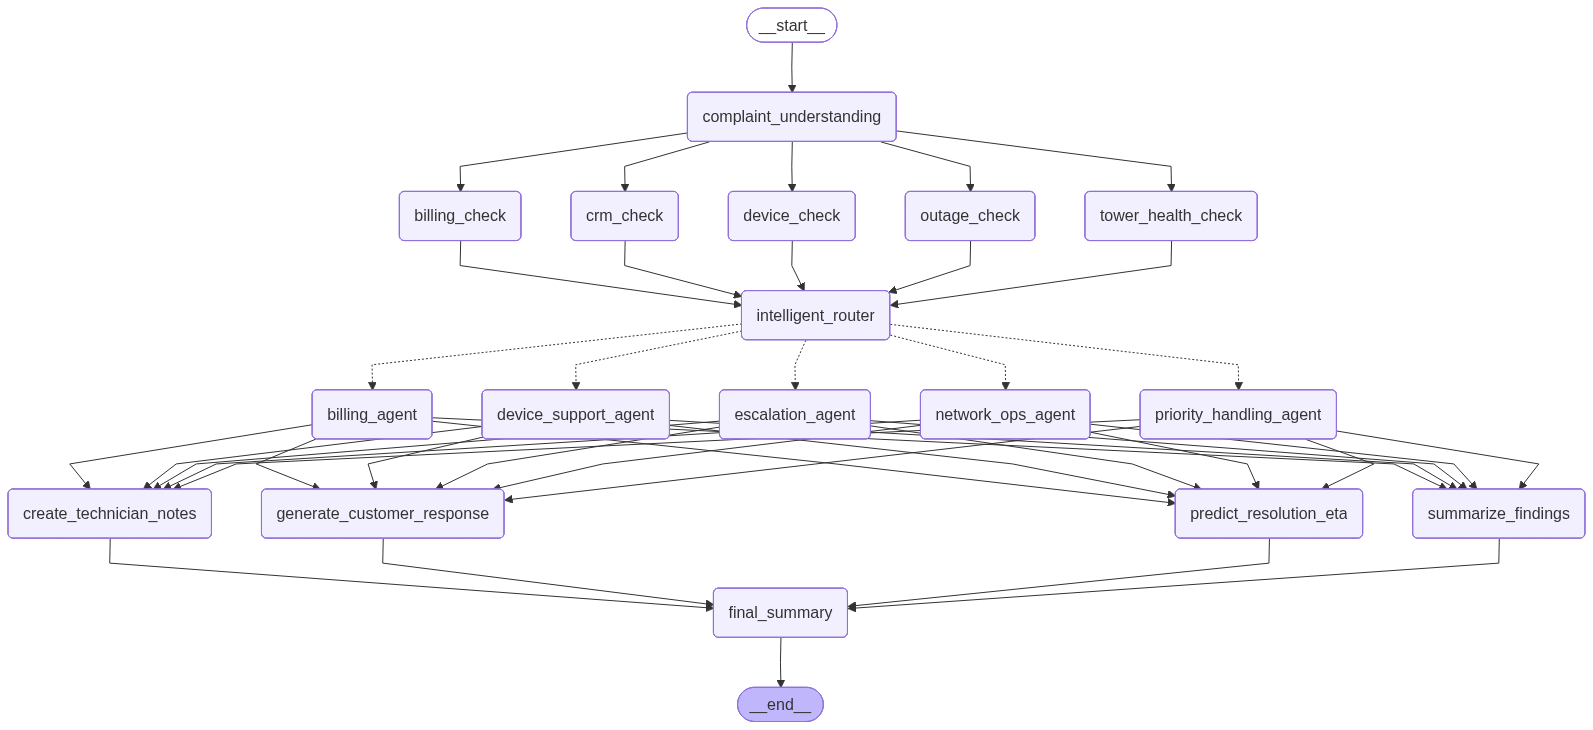

In [32]:
telecom_workflow

## Test Queries

In [33]:
# Query 1 — Network/speed issue
query_1 = {
    "query": "Internet is extremely slow since morning in our area."
}

result_1 = telecom_workflow.invoke(query_1)


              TELECOM INCIDENT FINAL REPORT

    CUSTOMER COMPLAINT
    --------------------------------------------------
    Internet is extremely slow since morning in our area.

    ISSUE ANALYSIS
    --------------------------------------------------
    Issue Type   : Internet Speed/Performance Degradation
    Severity     : High
    Impact Scope : Regional

    BACKEND FINDINGS
    --------------------------------------------------
    Tower Status   : NORMAL — No tower anomalies detected for reported issue type.
    CRM Status     : WARNING — Multiple complaints from same area logged in last 24 hours. Pattern detected.
    Billing Status : CLEAR — No billing anomalies associated with this complaint type.
    Device Status  : CLEAR — No device or SIM issues detected for this complaint type.
    Outage Status  : CONGESTION — High network traffic causing slowdowns. Optimization underway.

    ROUTING
    --------------------------------------------------
    Assigned Team : netwo

In [34]:
# Query 2 — Billing dispute
query_2 = {
    "query": "I was overcharged on my last invoice. I want a refund immediately."
}

result_2 = telecom_workflow.invoke(query_2)


              TELECOM INCIDENT FINAL REPORT

    CUSTOMER COMPLAINT
    --------------------------------------------------
    I was overcharged on my last invoice. I want a refund immediately.

    ISSUE ANALYSIS
    --------------------------------------------------
    Issue Type   : Billing Error
    Severity     : medium
    Impact Scope : individual

    BACKEND FINDINGS
    --------------------------------------------------
    Tower Status   : NORMAL — Tower infrastructure healthy. Issue is non-network related.
    CRM Status     : OK — No prior tickets found for this customer. First-time complaint.
    Billing Status : REVIEW NEEDED — Potential billing discrepancy detected. Account audit triggered.
    Device Status  : CLEAR — No device or SIM issues detected for this complaint type.
    Outage Status  : CLEAR — No active outages reported in monitoring systems.

    ROUTING
    --------------------------------------------------
    Assigned Team : billing_agent

    CUSTOMER 

In [35]:
# Query 3 — Device / SIM issue
query_3 = {
    "query": "My new SIM card is not activating on my 5G handset."
}

result_3 = telecom_workflow.invoke(query_3)


              TELECOM INCIDENT FINAL REPORT

    CUSTOMER COMPLAINT
    --------------------------------------------------
    My new SIM card is not activating on my 5G handset.

    ISSUE ANALYSIS
    --------------------------------------------------
    Issue Type   : SIM Activation Failure
    Severity     : medium
    Impact Scope : individual

    BACKEND FINDINGS
    --------------------------------------------------
    Tower Status   : NORMAL — Tower operating within acceptable parameters.
    CRM Status     : OK — No prior tickets found for this customer. First-time complaint.
    Billing Status : CLEAR — No billing anomalies associated with this complaint type.
    Device Status  : CHECK REQUIRED — Device/SIM compatibility issue suspected. Remote diagnostics initiated.
    Outage Status  : CLEAR — No active outages reported in monitoring systems.

    ROUTING
    --------------------------------------------------
    Assigned Team : device_support_agent

    CUSTOMER RESPO